# Compare Adaptation Methods: CoTTA vs PALM
Loads results from both methods and produces side-by-side comparison plots.

In [1]:
import sys, os
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load both results
cotta_path = Path('outputs/cotta/ctta_results.json')
palm_path = Path('outputs/palm/ctta_results.json')

if not cotta_path.exists():
    print('CoTTA results not found. Run 04_run_cotta.ipynb first.')
if not palm_path.exists():
    print('PALM results not found. Run 04\'_run_palm.ipynb first.')

cotta = json.load(open(cotta_path)) if cotta_path.exists() else None
palm = json.load(open(palm_path)) if palm_path.exists() else None

comparison_dir = Path('outputs/comparison')
comparison_dir.mkdir(parents=True, exist_ok=True)

def get_qwk(results, domain_idx, key):
    if not results or 'domain_results' not in results:
        return None
    dr = results['domain_results'][domain_idx]
    return dr[key]['qwk']

def get_aptos_dr(results):
    if not results:
        return None
    for dr in results.get('domain_results', []):
        if dr['domain_name'] == 'aptos2019':
            return dr
    return None

def get_idrid_dr(results):
    if not results:
        return None
    for dr in results.get('domain_results', []):
        if dr['domain_name'] == 'idrid':
            return dr
    return None

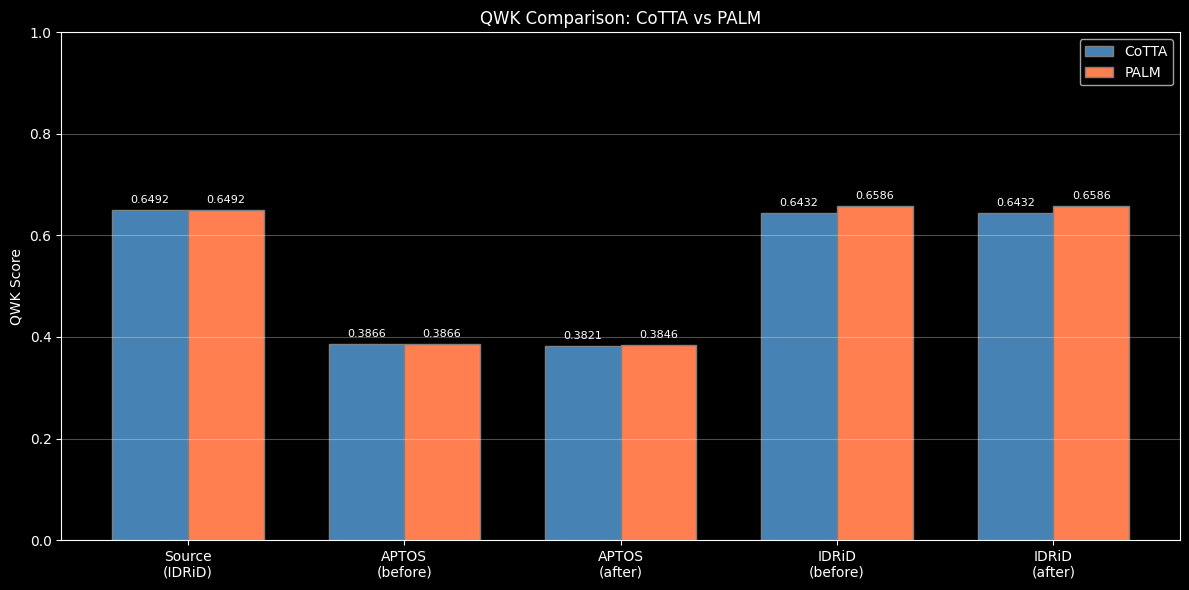

In [3]:
# --- 1. Side-by-side QWK comparison ---
if cotta and palm:
    methods = ['CoTTA', 'PALM']
    datasets = ['Source\n(IDRiD)', 'APTOS\n(before)', 'APTOS\n(after)', 'IDRiD\n(before)', 'IDRiD\n(after)']

    cotta_vals = [
        cotta['source_baseline']['qwk'],
        get_qwk(cotta, 0, 'baseline_metrics'),
        get_qwk(cotta, 0, 'post_adaptation_metrics'),
        get_qwk(cotta, 1, 'baseline_metrics'),
        get_qwk(cotta, 1, 'post_adaptation_metrics'),
    ]
    palm_vals = [
        palm['source_baseline']['qwk'],
        get_qwk(palm, 0, 'baseline_metrics'),
        get_qwk(palm, 0, 'post_adaptation_metrics'),
        get_qwk(palm, 1, 'baseline_metrics'),
        get_qwk(palm, 1, 'post_adaptation_metrics'),
    ]

    x = np.arange(len(datasets))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, cotta_vals, width, label='CoTTA', color='steelblue', edgecolor='gray')
    bars2 = ax.bar(x + width/2, palm_vals, width, label='PALM', color='coral', edgecolor='gray')

    for bars, vals in [(bars1, cotta_vals), (bars2, palm_vals)]:
        for bar, val in zip(bars, vals):
            if val is not None:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.4f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylabel('QWK Score')
    ax.set_title('QWK Comparison: CoTTA vs PALM')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(comparison_dir / 'qwk_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

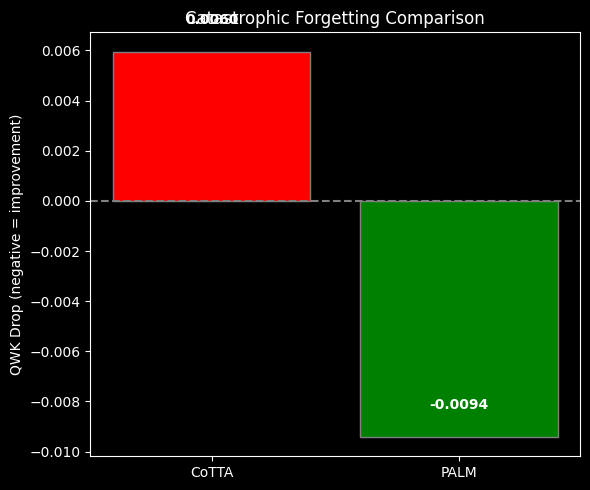

In [4]:
# --- 2. Forgetting comparison ---
if cotta and palm:
    methods = ['CoTTA', 'PALM']
    forgetting_vals = [
        cotta.get('forgetting', 0),
        palm.get('forgetting', 0),
    ]
    colors = ['red' if v > 0 else 'green' for v in forgetting_vals]

    plt.figure(figsize=(6, 5))
    bars = plt.bar(methods, forgetting_vals, color=colors, edgecolor='gray')
    for bar, val in zip(bars, forgetting_vals):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.ylabel('QWK Drop (negative = improvement)')
    plt.title('Catastrophic Forgetting Comparison')
    plt.axhline(y=0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.savefig(comparison_dir / 'forgetting_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

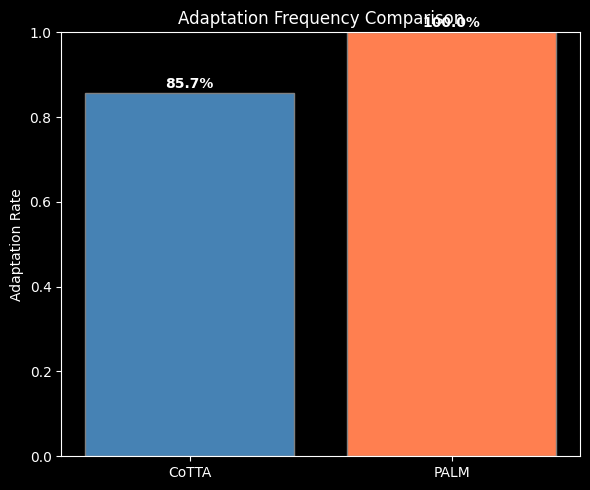

In [5]:
# --- 3. Adaptation rate comparison ---
if cotta and palm:
    methods = ['CoTTA', 'PALM']
    rates = [
        cotta.get('adaptation_rate', 0),
        palm.get('adaptation_rate', 0),
    ]

    plt.figure(figsize=(6, 5))
    bars = plt.bar(methods, rates, color=['steelblue', 'coral'], edgecolor='gray')
    for bar, val in zip(bars, rates):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.ylabel('Adaptation Rate')
    plt.title('Adaptation Frequency Comparison')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(comparison_dir / 'adaptation_rate_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

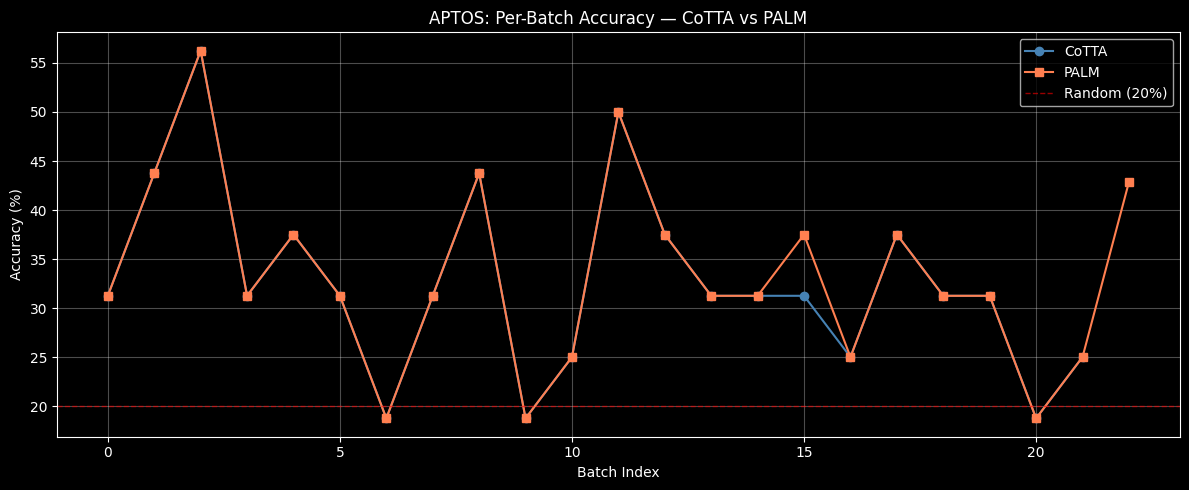

In [6]:
# --- 4. Per-batch accuracy comparison on APTOS ---
cotta_dr = get_aptos_dr(cotta)
palm_dr = get_aptos_dr(palm)

if cotta_dr and palm_dr:
    fig, ax = plt.subplots(figsize=(12, 5))

    for dr, label, color, marker in [(cotta_dr, 'CoTTA', 'steelblue', 'o'), (palm_dr, 'PALM', 'coral', 's')]:
        batch_ids = [bm['batch_idx'] for bm in dr['batch_metrics']]
        accs = [bm['accuracy'] * 100 for bm in dr['batch_metrics']]
        ax.plot(batch_ids, accs, marker + '-', label=label, color=color, markersize=6, linewidth=1.5)

    ax.axhline(y=20, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Random (20%)')
    ax.set_xlabel('Batch Index')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('APTOS: Per-Batch Accuracy — CoTTA vs PALM')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(comparison_dir / 'per_batch_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

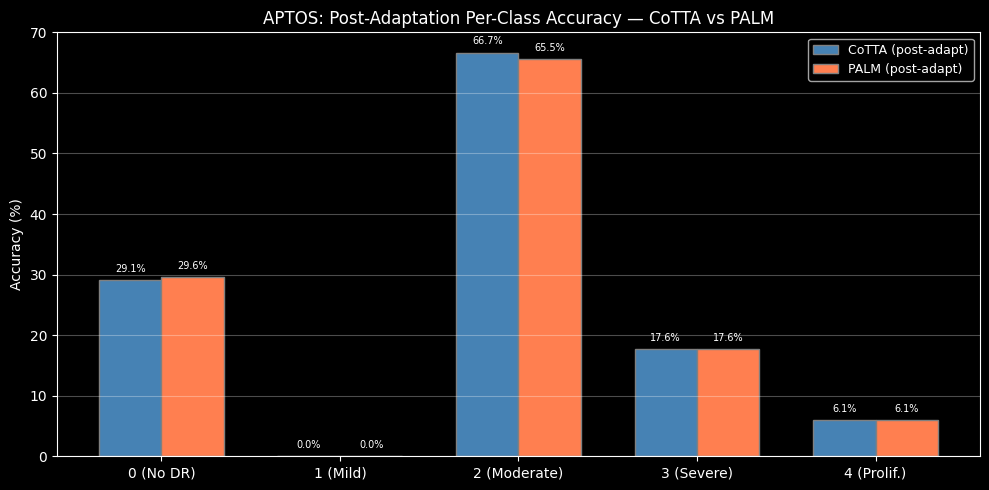

In [7]:
# --- 5. Per-class accuracy comparison on APTOS ---
if cotta_dr and palm_dr:
    classes = ['0 (No DR)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Prolif.)']
    x = np.arange(len(classes))
    width = 0.35

    cotta_post = [cotta_dr['post_adaptation_metrics']['per_class_accuracy'][str(i)] * 100 for i in range(5)]
    palm_post = [palm_dr['post_adaptation_metrics']['per_class_accuracy'][str(i)] * 100 for i in range(5)]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, cotta_post, width, label='CoTTA (post-adapt)', color='steelblue', edgecolor='gray')
    bars2 = ax.bar(x + width/2, palm_post, width, label='PALM (post-adapt)', color='coral', edgecolor='gray')

    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('APTOS: Post-Adaptation Per-Class Accuracy — CoTTA vs PALM')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

    for i in range(5):
        for bars, offset in [(bars1, -width/2), (bars2, width/2)]:
            val = cotta_post[i] if bars == bars1 else palm_post[i]
            ax.text(x[i] + offset, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.savefig(comparison_dir / 'per_class_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
# --- 6. Summary comparison table ---
if cotta and palm:
    print('=' * 75)
    print(f"{'Metric':<30} {'CoTTA':<20} {'PALM':<20}")
    print('=' * 75)
    print(f"{'Source Baseline QWK':<30} {cotta['source_baseline']['qwk']:<20.4f} {palm['source_baseline']['qwk']:<20.4f}")

    for label, key in [('APTOS Baseline QWK', 0), ('APTOS Post-adapt QWK', 0)]:
        c_val = cotta['domain_results'][key]['baseline_metrics']['qwk'] if 'Baseline' in label else cotta['domain_results'][key]['post_adaptation_metrics']['qwk']
        p_val = palm['domain_results'][key]['baseline_metrics']['qwk'] if 'Baseline' in label else palm['domain_results'][key]['post_adaptation_metrics']['qwk']
        print(f"{label:<30} {c_val:<20.4f} {p_val:<20.4f}")

    for label, key in [('APTOS Adaptations', 0), ('IDRiD Adaptations', 1)]:
        c_val = f"{cotta['domain_results'][key]['num_adaptations']}/{cotta['domain_results'][key]['total_batches']}"
        p_val = f"{palm['domain_results'][key]['num_adaptations']}/{palm['domain_results'][key]['total_batches']}"
        print(f"{label:<30} {c_val:<20} {p_val:<20}")

    print(f"{'Forgetting':<30} {cotta.get('forgetting', 0):<20.4f} {palm.get('forgetting', 0):<20.4f}")
    print(f"{'Adaptation Rate':<30} {cotta.get('adaptation_rate', 0):<20.2%} {palm.get('adaptation_rate', 0):<20.2%}")
    print('=' * 75)

Metric                         CoTTA                PALM                
Source Baseline QWK            0.6492               0.6492              
APTOS Baseline QWK             0.3866               0.3866              
APTOS Post-adapt QWK           0.3821               0.3846              
APTOS Adaptations              22/22                23/23               
IDRiD Adaptations              2/6                  7/7                 
Forgetting                     0.0060               -0.0094             
Adaptation Rate                85.71%               100.00%             
